In [110]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

In [111]:
# Load the dataset
df = pd.read_csv("aqi_dataset.csv")
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,wd,WSPM,AQI,AQI_Category
0,1.0,2013.0,3.0,1.0,0.0,NaN,6.0,13.000000,7.0,300.0,85.0,-2.3,1020.8,-19.7,nw,0.500000,85.0,Satisfactory
1,2.0,2013.0,3.0,1.0,1.0,3.000000,3.0,6.000000,6.0,300.0,85.0,-2.5,1021.3,-19.0,SsE,0.700000,85.0,Satisfactory
2,3.0,2013.0,3.0,8.0,7.0,3.000000,NaN,22.000000,13.0,400.0,74.0,-3.0,1021.3,-19.9,sse,14.954585,74.0,Satisfactory
3,4.0,2013.0,3.0,1.0,3.0,3.000000,6.0,12.000000,8.0,300.0,81.0,-3.6,1021.8,-19.1,nnw,1.000000,81.0,Satisfactory
4,5.0,2013.0,3.0,1.0,7.0,3.000000,3.0,14.000000,8.0,300.0,81.0,-3.5,1022.3,-19.4,nne,2.100000,81.0,Satisfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38652,18119.0,2015.0,3.0,25.0,22.0,125.000000,174.0,22.000000,91.0,1400.0,34.0,11.7,1020.6,0.1,Wnw,1.100000,304.0,Very Poor
38653,NaN,2014.0,11.0,18.0,19.0,-86.801518,199.0,43.000000,97.0,2900.0,7.0,6.6,1019.0,-6.4,Wsw,1.000000,245.0,Poor
38654,24171.0,2015.0,12.0,3.0,2.0,9.000000,NaN,-19.479078,NaN,600.0,25.0,-1.6,1010.8,-15.1,ENE,5.100000,33.0,Good
38655,30287.0,2016.0,8.0,13.0,22.0,795.631575,18.0,2.000000,56.0,700.0,16.0,23.3,997.9,18.6,n,1.500000,70.0,Satisfactory


In [112]:
#BASIC DATA INSPECTION
# structure of dataset
df.info()

# Statistical summary
df.describe()

# Count missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 38657 entries, 0 to 38656
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   No            34957 non-null  float64
 1   year          38657 non-null  float64
 2   month         38657 non-null  float64
 3   day           38657 non-null  float64
 4   hour          38657 non-null  float64
 5   PM2.5         33165 non-null  float64
 6   PM10          33329 non-null  float64
 7   SO2           33254 non-null  float64
 8   NO2           33226 non-null  float64
 9   CO            32409 non-null  float64
 10  O3            33260 non-null  float64
 11  TEMP          36691 non-null  float64
 12  PRES          36680 non-null  float64
 13  DEWP          36714 non-null  float64
 14  wd            38657 non-null  str    
 15  WSPM          36723 non-null  float64
 16  AQI           38212 non-null  float64
 17  AQI_Category  38212 non-null  str    
dtypes: float64(16), str(2)
memory usage: 

No              3700
year               0
month              0
day                0
hour               0
PM2.5           5492
PM10            5328
SO2             5403
NO2             5431
CO              6248
O3              5397
TEMP            1966
PRES            1977
DEWP            1943
wd                 0
WSPM            1934
AQI              445
AQI_Category     445
dtype: int64

In [113]:
#DROP USELESS COLUMN

df.drop(columns=['No','year','month','day','hour'], inplace=True)

In [114]:
# HANDLE MISSING VALUES 

df['PM2.5']=df['PM2.5'].fillna(df['PM2.5'].median())

df['PM10']=df['PM10'].fillna(df['PM10'].median())

df['SO2']=df['SO2'].fillna(df['SO2'].mean())

df['NO2']=df['NO2'].fillna(df['NO2'].median())

df['CO']=df['CO'].fillna(df['CO'].mean())

df['O3']=df['O3'].fillna(df['O3'].median())

df['TEMP']=df['TEMP'].fillna(df['TEMP'].mean())

df['PRES']=df['PRES'].fillna(df['PRES'].mean())

df['DEWP']=df['DEWP'].fillna(df['DEWP'].mean())

df['WSPM']=df['WSPM'].fillna(df['WSPM'].mean())

In [115]:
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,wd,WSPM,AQI,AQI_Category
0,46.000000,6.0,13.000000,7.0,300.0,85.0,-2.3,1020.8,-19.7,nw,0.500000,85.0,Satisfactory
1,3.000000,3.0,6.000000,6.0,300.0,85.0,-2.5,1021.3,-19.0,SsE,0.700000,85.0,Satisfactory
2,3.000000,72.0,22.000000,13.0,400.0,74.0,-3.0,1021.3,-19.9,sse,14.954585,74.0,Satisfactory
3,3.000000,6.0,12.000000,8.0,300.0,81.0,-3.6,1021.8,-19.1,nnw,1.000000,81.0,Satisfactory
4,3.000000,3.0,14.000000,8.0,300.0,81.0,-3.5,1022.3,-19.4,nne,2.100000,81.0,Satisfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38652,125.000000,174.0,22.000000,91.0,1400.0,34.0,11.7,1020.6,0.1,Wnw,1.100000,304.0,Very Poor
38653,-86.801518,199.0,43.000000,97.0,2900.0,7.0,6.6,1019.0,-6.4,Wsw,1.000000,245.0,Poor
38654,9.000000,72.0,-19.479078,36.0,600.0,25.0,-1.6,1010.8,-15.1,ENE,5.100000,33.0,Good
38655,795.631575,18.0,2.000000,56.0,700.0,16.0,23.3,997.9,18.6,n,1.500000,70.0,Satisfactory


In [116]:
# FIX INCONSISTENT DATA

df['wd'] = df['wd'].str.upper()

In [117]:
# REMOVE DUPLICATES

df.drop_duplicates(inplace=True)

In [118]:
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,wd,WSPM,AQI,AQI_Category
0,46.000000,6.0,13.000000,7.0,300.000000,85.0,-2.3,1020.8,-19.7,NW,0.500000,85.0,Satisfactory
1,3.000000,3.0,6.000000,6.0,300.000000,85.0,-2.5,1021.3,-19.0,SSE,0.700000,85.0,Satisfactory
2,3.000000,72.0,22.000000,13.0,400.000000,74.0,-3.0,1021.3,-19.9,SSE,14.954585,74.0,Satisfactory
3,3.000000,6.0,12.000000,8.0,300.000000,81.0,-3.6,1021.8,-19.1,NNW,1.000000,81.0,Satisfactory
4,3.000000,3.0,14.000000,8.0,300.000000,81.0,-3.5,1022.3,-19.4,NNE,2.100000,81.0,Satisfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38651,107.000000,130.0,18.587651,26.0,1330.449292,182.0,30.7,992.7,20.3,E,2.700000,256.0,Poor
38652,125.000000,174.0,22.000000,91.0,1400.000000,34.0,11.7,1020.6,0.1,WNW,1.100000,304.0,Very Poor
38653,-86.801518,199.0,43.000000,97.0,2900.000000,7.0,6.6,1019.0,-6.4,WSW,1.000000,245.0,Poor
38654,9.000000,72.0,-19.479078,36.0,600.000000,25.0,-1.6,1010.8,-15.1,ENE,5.100000,33.0,Good


In [119]:
# Handle outliers in PM2.5 using IQR

Q1 = df['PM2.5'].quantile(0.25)
Q3 = df['PM2.5'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['PM2.5'] >= lower) & (df['PM2.5'] <= upper)]

In [120]:
# Handle outliers in PM10

Q1 = df['PM10'].quantile(0.25)
Q3 = df['PM10'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['PM10'] >= lower) & (df['PM10'] <= upper)]

In [121]:
# Handle outliers in SO2

Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['SO2'] >= lower) & (df['SO2'] <= upper)]

In [122]:
# Handle outliers in NO2

Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['NO2'] >= lower) & (df['NO2'] <= upper)]

In [123]:
# Handle outliers in CO

Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['CO'] >= lower) & (df['CO'] <= upper)]

In [124]:
# Handle outliers in O3

Q1 = df['O3'].quantile(0.25)
Q3 = df['O3'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['O3'] >= lower) & (df['O3'] <= upper)]

In [125]:
# Handle outliers in TEMP

Q1 = df['TEMP'].quantile(0.25)
Q3 = df['TEMP'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['TEMP'] >= lower) & (df['TEMP'] <= upper)]

In [126]:
# Handle outliers in PRES

Q1 = df['PRES'].quantile(0.25)
Q3 = df['PRES'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['PRES'] >= lower) & (df['PRES'] <= upper)]

In [127]:
# Handle outliers in DEWP

Q1 = df['DEWP'].quantile(0.25)
Q3 = df['DEWP'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['DEWP'] >= lower) & (df['DEWP'] <= upper)]

In [128]:
# Handle outliers in WSPM

Q1 = df['WSPM'].quantile(0.25)
Q3 = df['WSPM'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['WSPM'] >= lower) & (df['WSPM'] <= upper)]

In [129]:
df.rename(columns={
    'DEWP': 'Humidity',   
    'RAIN': 'Rainfall',
    'WSPM': 'WindSpeed',
    'wd': 'WindDirection'
}, inplace=True)

In [130]:
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,Humidity,WindDirection,WindSpeed,AQI,AQI_Category
0,46.0,6.0,13.000000,7.0,300.000000,85.0,-2.3,1020.800000,-19.700000,NW,0.5,85.0,Satisfactory
1,3.0,3.0,6.000000,6.0,300.000000,85.0,-2.5,1021.300000,-19.000000,SSE,0.7,85.0,Satisfactory
3,3.0,6.0,12.000000,8.0,300.000000,81.0,-3.6,1021.800000,-19.100000,NNW,1.0,81.0,Satisfactory
4,3.0,3.0,14.000000,8.0,300.000000,81.0,-3.5,1022.300000,-19.400000,NNE,2.1,81.0,Satisfactory
5,46.0,3.0,10.000000,17.0,400.000000,71.0,-4.5,1022.600000,-19.500000,N,1.7,71.0,Satisfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38638,59.0,59.0,18.587651,10.0,600.000000,22.0,22.5,998.300000,21.800000,SW,0.6,98.0,Satisfactory
38641,21.0,21.0,2.000000,38.0,1330.449292,17.0,9.4,1009.880803,6.300000,ENE,1.5,48.0,Good
38642,46.0,39.0,34.000000,37.0,700.000000,35.0,4.6,1016.800000,-11.900000,NW,0.5,46.0,Good
38645,22.0,23.0,4.000000,36.0,400.000000,46.0,17.4,1015.100000,4.513626,WSW,2.0,123.0,Moderate


In [131]:
# Fix negative values using absolute function

cols = ['PM2.5','PM10','SO2','NO2','CO','O3',
        'TEMP','PRES','Humidity','WindSpeed']

for col in cols:
    df[col] = abs(df[col])

In [132]:
#Adding AQI Category Column

aqi_category = []

for i in df['AQI']:
    if pd.isna(i):
        aqi_category.append(None)
    elif i <= 50:
        aqi_category.append('Good')
    elif i <= 100:
        aqi_category.append('Satisfactory')
    elif i <= 200:
        aqi_category.append('Moderate')
    elif i <= 300:
        aqi_category.append('Poor')
    elif i <= 400:
        aqi_category.append('Very Poor')
    else:
        aqi_category.append('Severe')

df['AQI_Category'] = aqi_category

In [133]:
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,Humidity,WindDirection,WindSpeed,AQI,AQI_Category
0,46.0,6.0,13.000000,7.0,300.000000,85.0,2.3,1020.800000,19.700000,NW,0.5,85.0,Satisfactory
1,3.0,3.0,6.000000,6.0,300.000000,85.0,2.5,1021.300000,19.000000,SSE,0.7,85.0,Satisfactory
3,3.0,6.0,12.000000,8.0,300.000000,81.0,3.6,1021.800000,19.100000,NNW,1.0,81.0,Satisfactory
4,3.0,3.0,14.000000,8.0,300.000000,81.0,3.5,1022.300000,19.400000,NNE,2.1,81.0,Satisfactory
5,46.0,3.0,10.000000,17.0,400.000000,71.0,4.5,1022.600000,19.500000,N,1.7,71.0,Satisfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38638,59.0,59.0,18.587651,10.0,600.000000,22.0,22.5,998.300000,21.800000,SW,0.6,98.0,Satisfactory
38641,21.0,21.0,2.000000,38.0,1330.449292,17.0,9.4,1009.880803,6.300000,ENE,1.5,48.0,Good
38642,46.0,39.0,34.000000,37.0,700.000000,35.0,4.6,1016.800000,11.900000,NW,0.5,46.0,Good
38645,22.0,23.0,4.000000,36.0,400.000000,46.0,17.4,1015.100000,4.513626,WSW,2.0,123.0,Moderate


In [134]:
df.to_csv("cleaned_aqi_dataset.csv")

In [135]:
#Standardization

from sklearn.preprocessing import StandardScaler

cols = ['PM2.5','PM10','SO2','NO2','CO','O3',
        'TEMP','PRES','Humidity','WindSpeed']

scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

In [136]:
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,Humidity,WindDirection,WindSpeed,AQI,AQI_Category
0,-0.045104,-1.393819,0.263267,-1.600605,-1.213525,1.009519,-1.434223,1.357767,1.132839,NW,-1.258817,85.0,Satisfactory
1,-1.168025,-1.462171,-0.486830,-1.654670,-1.213525,1.009519,-1.412498,1.408229,1.029511,SSE,-1.045761,85.0,Satisfactory
3,-1.168025,-1.393819,0.156110,-1.546540,-1.213525,0.891008,-1.293008,1.458690,1.044272,NNW,-0.726176,81.0,Satisfactory
4,-1.168025,-1.462171,0.370423,-1.546540,-1.213525,0.891008,-1.303871,1.509151,1.088555,NNE,0.445635,81.0,Satisfactory
5,-0.045104,-1.462171,-0.058203,-1.059952,-1.011101,0.594729,-1.195243,1.539428,1.103317,N,0.019522,71.0,Satisfactory
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38638,0.294384,-0.186273,0.862021,-1.438409,-0.606254,-0.857036,0.760050,-0.912990,1.442825,SW,-1.152289,98.0,Satisfactory
38641,-0.697965,-1.052061,-0.915457,0.075419,0.872347,-1.005175,-0.662969,0.255774,-0.845165,ENE,-0.193535,48.0,Good
38642,-0.045104,-0.641951,2.513556,0.021354,-0.403831,-0.471874,-1.184380,0.954077,-0.018536,NW,-1.258817,46.0,Good
38645,-0.671850,-1.006493,-0.701143,-0.032712,-1.011101,-0.145967,0.206050,0.782509,-1.108855,WSW,0.339106,123.0,Moderate


In [137]:
df=df.head(10000)

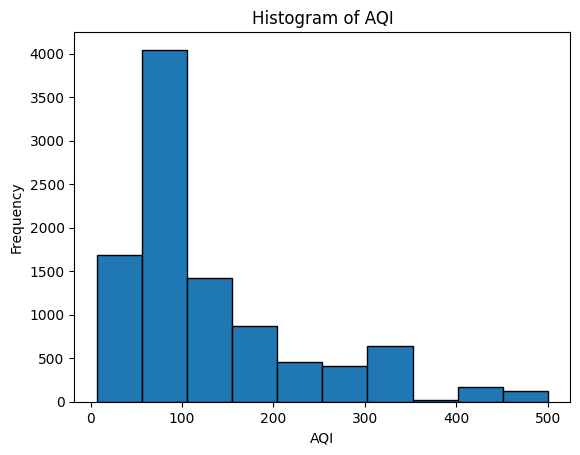

In [138]:
#Histogram for AQI

plt.hist(df['AQI'],edgecolor='black')
plt.title('Histogram of AQI')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

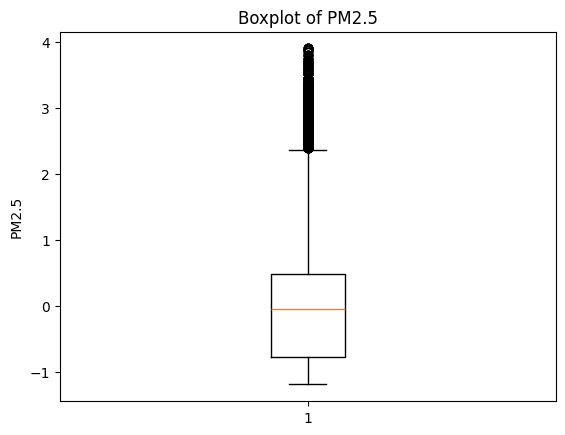

In [139]:
#Box plot for PM2.5
plt.boxplot(df['PM2.5'])
plt.title('Boxplot of PM2.5')
plt.ylabel('PM2.5')
plt.show()

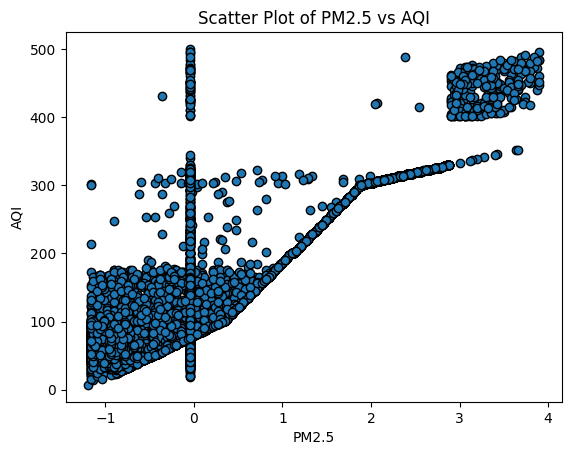

In [140]:
#Scatter plot between PM2.5 and AQI

plt.scatter(df['PM2.5'], df['AQI'],edgecolors="Black")
plt.title('Scatter Plot of PM2.5 vs AQI')
plt.xlabel('PM2.5')
plt.ylabel('AQI')
plt.show()

In [141]:
df = df.dropna(subset=['AQI'])

In [142]:
corr_with_aqi = df.corr(numeric_only=True)['AQI'].sort_values(ascending=False)
print(corr_with_aqi)

AQI          1.000000
PM2.5        0.855622
PM10         0.715336
CO           0.517114
NO2          0.320187
TEMP         0.191214
SO2          0.138157
O3           0.066361
Humidity    -0.023907
WindSpeed   -0.142281
PRES        -0.207522
Name: AQI, dtype: float64


In [143]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

In [144]:
X = df[['PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'TEMP', 'O3', 'Humidity', 'WindSpeed', 'PRES']]
y = df['AQI']

In [145]:
model = LinearRegression()

sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=5,
    direction='forward'
)

sfs.fit(X, y)

selected_features = X.columns[sfs.get_support()]
print(selected_features)

Index(['PM2.5', 'PM10', 'CO', 'TEMP', 'O3'], dtype='str')


In [146]:
#Forward feature selection selected PM2.5, PM10, CO, TEMP, and O3 as the most relevant features for predicting AQI.

In [147]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [148]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [149]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [150]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

print("Lasso Coefficients:")  
print(pd.Series(lasso.coef_, index=X.columns))

Lasso Coefficients:
PM2.5        64.200240
PM10         21.974519
CO            8.825681
NO2          -1.996499
SO2          -3.334663
TEMP          6.199730
O3            8.511182
Humidity      0.819723
WindSpeed     3.912968
PRES          0.000000
dtype: float64


In [151]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

print("Ridge Coefficients:")
print(pd.Series(ridge.coef_, index=X.columns))

Ridge Coefficients:
PM2.5        64.218415
PM10         22.119699
CO            9.016152
NO2          -2.140273
SO2          -3.498733
TEMP          6.433743
O3            8.544709
Humidity      0.881858
WindSpeed     4.006591
PRES          0.301172
dtype: float64


In [152]:
y = df['AQI_Category']

In [153]:
# Selecting key features
X = df[['PM2.5', 'PM10', 'CO', 'TEMP', 'O3']]
y = df['AQI_Category']

In [154]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [155]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [156]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6959390862944163
Classification Report:
               precision    recall  f1-score   support

        Good       0.62      0.31      0.41       213
    Moderate       0.68      0.68      0.68       484
        Poor       0.62      0.56      0.59       180
Satisfactory       0.73      0.86      0.79       882
      Severe       0.78      0.48      0.60        60
   Very Poor       0.64      0.60      0.62       151

    accuracy                           0.70      1970
   macro avg       0.68      0.58      0.61      1970
weighted avg       0.69      0.70      0.68      1970



In [157]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')

In [158]:
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [159]:
y_pred = log_reg.predict(X_test)

In [160]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.5812182741116751
              precision    recall  f1-score   support

        Good       0.39      0.79      0.52       213
    Moderate       0.62      0.60      0.61       484
        Poor       0.40      0.54      0.46       180
Satisfactory       0.81      0.55      0.66       882
      Severe       0.43      0.65      0.52        60
   Very Poor       0.47      0.39      0.43       151

    accuracy                           0.58      1970
   macro avg       0.52      0.59      0.53      1970
weighted avg       0.64      0.58      0.59      1970



In [161]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[169   2   0  42   0   0]
 [ 10 291 113  65   0   5]
 [  0  23  98   7   2  50]
 [252 138   3 489   0   0]
 [  0   4   5   1  39  11]
 [  0  14  27   1  50  59]]


In [162]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_lr = grid.best_estimator_

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Score: 0.6953915881073242


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

In [175]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [176]:
X = df[['PM2.5', 'PM10', 'CO', 'TEMP', 'O3']]
y = df['AQI_Category']

In [177]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [178]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [179]:
#Hyperparameter Tuning to find best value of k
from sklearn.model_selection import GridSearchCV
param_knn = {
    'n_neighbors':[3, 5, 7, 9, 11],
    'weights':['uniform', 'distance'],
    'metric':['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5)

grid_knn.fit(X_train,y_train)

print('Best KNN Parameters:', grid_knn.best_params_)

Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


In [180]:
#Using Hyperparameter tuning in Support vector Machine(SVM)
grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    {'C': [0.1,1,10,100], 'kernel': ['rbf','poly'], 'gamma': ['scale','auto']},
    cv=5, scoring='accuracy', n_jobs=-1)

grid_svm.fit(X_train,y_train)

print(f"  Best: {grid_svm.best_params_}")

  Best: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}


In [181]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [182]:
y_pred = knn.predict(X_test)

In [183]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.801522842639594
              precision    recall  f1-score   support

        Good       0.63      0.71      0.67       213
    Moderate       0.83      0.81      0.82       484
        Poor       0.76      0.72      0.74       180
Satisfactory       0.85      0.86      0.86       882
      Severe       0.71      0.57      0.63        60
   Very Poor       0.79      0.73      0.76       151

    accuracy                           0.80      1970
   macro avg       0.76      0.73      0.74      1970
weighted avg       0.80      0.80      0.80      1970

[[151   0   0  62   0   0]
 [  5 393  21  61   3   1]
 [  1  31 129   9   0  10]
 [ 82  35   2 762   0   1]
 [  1   4   1   2  34  18]
 [  1  10  17   2  11 110]]


In [190]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

In [191]:
log_pred = log_reg.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.5812182741116751


In [192]:
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.801522842639594


In [193]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN'],
    'Accuracy': [log_acc, knn_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.581218
1,KNN,0.801523


In [194]:
print("Logistic Regression Report:\n")
print(classification_report(y_test, log_pred, zero_division=0))

print("\nKNN Report:\n")
print(classification_report(y_test, knn_pred, zero_division=0))

Logistic Regression Report:

              precision    recall  f1-score   support

        Good       0.39      0.79      0.52       213
    Moderate       0.62      0.60      0.61       484
        Poor       0.40      0.54      0.46       180
Satisfactory       0.81      0.55      0.66       882
      Severe       0.43      0.65      0.52        60
   Very Poor       0.47      0.39      0.43       151

    accuracy                           0.58      1970
   macro avg       0.52      0.59      0.53      1970
weighted avg       0.64      0.58      0.59      1970


KNN Report:

              precision    recall  f1-score   support

        Good       0.63      0.71      0.67       213
    Moderate       0.83      0.81      0.82       484
        Poor       0.76      0.72      0.74       180
Satisfactory       0.85      0.86      0.86       882
      Severe       0.71      0.57      0.63        60
   Very Poor       0.79      0.73      0.76       151

    accuracy                      

In [195]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

In [196]:
log_pred = log_reg.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.5812182741116751


In [197]:
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.801522842639594


In [198]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN'],
    'Accuracy': [log_acc, knn_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.581218
1,KNN,0.801523


In [199]:
print("Logistic Regression Report:\n")
print(classification_report(y_test, log_pred, zero_division=0))

print("\nKNN Report:\n")
print(classification_report(y_test, knn_pred, zero_division=0))

Logistic Regression Report:

              precision    recall  f1-score   support

        Good       0.39      0.79      0.52       213
    Moderate       0.62      0.60      0.61       484
        Poor       0.40      0.54      0.46       180
Satisfactory       0.81      0.55      0.66       882
      Severe       0.43      0.65      0.52        60
   Very Poor       0.47      0.39      0.43       151

    accuracy                           0.58      1970
   macro avg       0.52      0.59      0.53      1970
weighted avg       0.64      0.58      0.59      1970


KNN Report:

              precision    recall  f1-score   support

        Good       0.63      0.71      0.67       213
    Moderate       0.83      0.81      0.82       484
        Poor       0.76      0.72      0.74       180
Satisfactory       0.85      0.86      0.86       882
      Severe       0.71      0.57      0.63        60
   Very Poor       0.79      0.73      0.76       151

    accuracy                      

In [200]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [201]:
# 3. Drop unwanted columns (IMPORTANT)
# Do NOT use AQI for classification
df = df.drop(columns=['AQI'], errors='ignore')

In [202]:
# 4. Handle missing values
df = df.dropna()

In [203]:
# 5. Select features (based on your feature selection)
X = df[['PM2.5', 'PM10', 'CO', 'TEMP', 'O3']]

# Target
y = df['AQI_Category']

In [204]:
# 6. Encode target labels (text → numbers)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [205]:
# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

In [206]:
# 8. Feature scaling 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [207]:
# 9. Train SVM Classifier
svm = SVC(kernel='rbf', probability=True)

svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [208]:
# 10. Predictions
y_pred = svm.predict(X_test_scaled)

In [209]:
#Using Hyperparameter tuning in Support vector Machine(SVM)
grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    {'C': [0.1,1,10,100], 'kernel': ['rbf','poly'], 'gamma': ['scale','auto']},
    cv=5, scoring='accuracy', n_jobs=-1)

grid_svm.fit(X_train,y_train)

print(f"  Best: {grid_svm.best_params_}")

  Best: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


In [210]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8411167512690355


In [211]:
# Classification Report (Precision, Recall, F1)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:

              precision    recall  f1-score   support

        Good       0.71      0.61      0.65       213
    Moderate       0.85      0.89      0.87       484
        Poor       0.91      0.76      0.83       180
Satisfactory       0.84      0.91      0.88       882
      Severe       0.89      0.70      0.79        60
   Very Poor       0.91      0.76      0.83       151

    accuracy                           0.84      1970
   macro avg       0.85      0.77      0.81      1970
weighted avg       0.84      0.84      0.84      1970



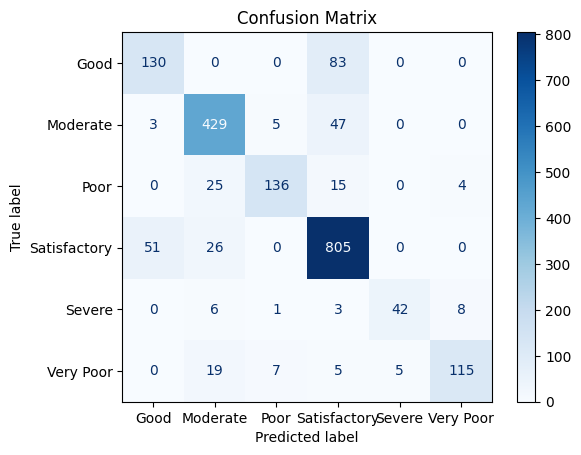

In [212]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

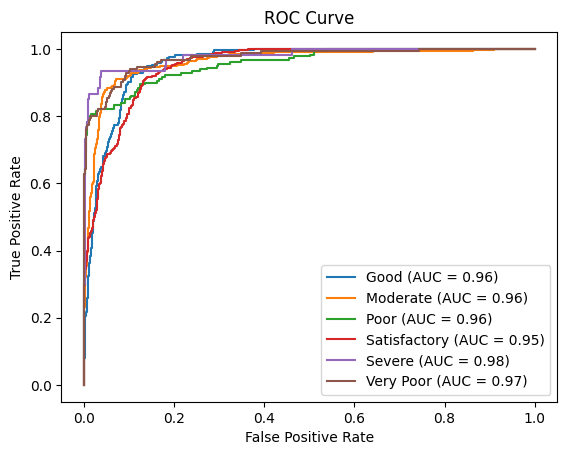

In [213]:
# ROC Curve (One vs Rest)
y_prob = svm.predict_proba(X_test_scaled)

for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {auc(fpr, tpr):.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [214]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC

# Features and target
X = df[['PM2.5', 'PM10', 'CO', 'TEMP', 'O3']]
y = df['AQI_Category']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Best model (SVM)
model = SVC(kernel='rbf')
model.fit(X_train, y_train)



In [ ]:
# Save using pickle
with open('best_model.pkl','wb') as f:
    pickle.dump(model,f)

with open('scaler.pkl','wb') as f:
    pickle.dump(scaler,f)

with open('label_encoder.pkl','wb') as f:
    pickle.dump(le,f)

print("Model saved successfully")